# Spotiflow in Python

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/spot_detection_with_spotiflow.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/spot_detection_with_spotiflow_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [173]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "spotiflow",
#     "ndv[jupyter,pygfx]",
#     "jupyter-rfb<=0.5.4",
# ]
# ///

In [174]:
import matplotlib.pyplot as plt
import ndv
import numpy as np
from spotiflow.model import Spotiflow
from spotiflow.sample_data import test_image_hybiss_2d

In [175]:
# Load sample image
img = test_image_hybiss_2d()

In [176]:
print("Image shape:", img.shape)

Image shape: (512, 512)


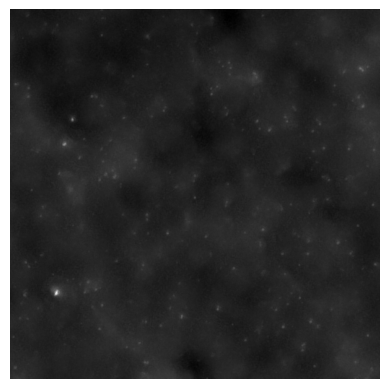

In [177]:
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [178]:
ndv.imshow(img)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [179]:
# Load a pretrained model
model = Spotiflow.from_pretrained("general")
# Or load your own trained model from folder
# model = Spotiflow.from_folder("./mymodel")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general


In [180]:
# Predict
points, details = model.predict(img)

INFO:spotiflow.model.spotiflow:Will use device: mps:0
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (512, 512)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 512, 1)
INFO:spotiflow.model.spotiflow:Found 212 spots


points contains the coordinates of the detected spots, the attributes 'heatmap' and 'flow' of `details` contain the predicted full resolution heatmap and the prediction of the stereographic flow respectively (access them by `details.heatmap` or `details.flow`). Retrieved spot intensities are found in `details.intens`.

In [181]:
points.shape

(212, 2)

In [182]:
print(points[0])

[510.04109436 272.6645605 ]


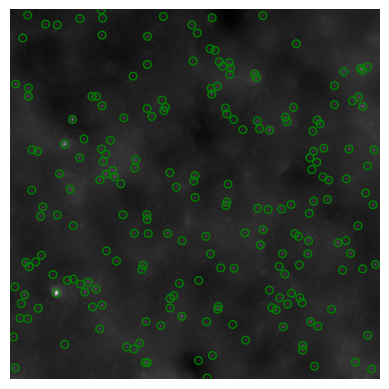

In [183]:
points_y = points[:, 0]
points_x = points[:, 1]

plt.imshow(img, cmap="gray")
plt.scatter(points_x, points_y, s=30, edgecolor="g", facecolor="none")
plt.axis("off")
plt.show()

In [184]:
ndv.imshow(details.heatmap, default_lut={"cmap": "hot"})

RFBOutputContext()

<IPython.core.display.Javascript object>

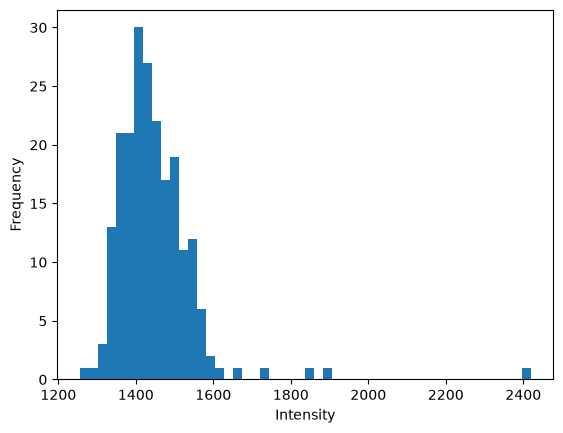

In [185]:
plt.hist(details.intens, bins=50)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

In [186]:
import tifffile
img = tifffile.imread("/Users/fdrgsp/Documents/git/bobiac-book/_internal/3d_spots.tif")

In [187]:
ndv.imshow(img)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [188]:
# Load a pretrained model
model = Spotiflow.from_pretrained("smfish_3d")

INFO:spotiflow.model.spotiflow:Loading pretrained model: smfish_3d


In [189]:
prob_thresh = 0.38
points, details = model.predict(img, prob_thresh=prob_thresh)

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = 0.38, min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (256, 256, 256)
INFO:spotiflow.model.spotiflow:Predicting with (2, 1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 256, 256, 1)
INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


Predicting tiles:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 50 spots


In [190]:
masked_heatmap = np.where(details.heatmap > 0.3, details.heatmap, 0)
ndv.imshow(masked_heatmap, default_lut={"cmap": "hot"})

RFBOutputContext()

<IPython.core.display.Javascript object>